In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
df = pd.read_csv('netflix_titles.csv')
print(f"Размер датасета: {df.shape}")

print("\nПервые 5 строк:")
df.head()

Размер датасета: (8807, 12)

Первые 5 строк:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Последние 5 строк:")
df.tail()

print("\nИнформация о данных:")
df.info()

Последние 5 строк:

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [4]:
print("Статистика для числовых данных:")
df.describe()

print("\nСтатистика для категориальных данных:")
df.describe(include='object')

Статистика для числовых данных:

Статистика для категориальных данных:


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


Пропущенные значения:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Количество дубликатов: 0


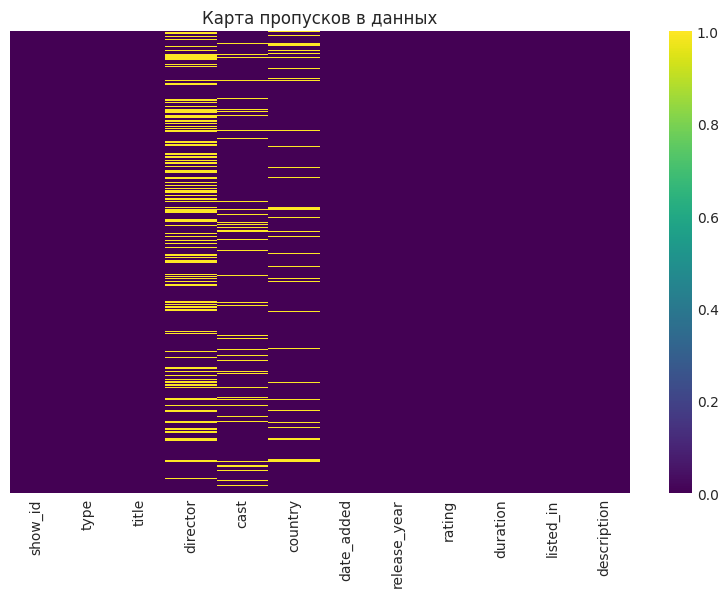

In [5]:
print("Пропущенные значения:")
print(df.isnull().sum())

print(f"\nКоличество дубликатов: {df.duplicated().sum()}")

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Карта пропусков в данных')
plt.show()

In [6]:
df_clean = df.copy()

print("Стратегия обработки пропусков:")
print("- director: заполняем 'Unknown Director'")
print("- cast: заполняем 'Unknown Cast'")
print("- country: заполняем модой (наиболее частой страной)")
print("- date_added: удаляем строки с пропусками")
print("- rating: заполняем модой")
print("- duration: удаляем строки с пропусками")

df_clean['director'].fillna('Unknown Director', inplace=True)
df_clean['cast'].fillna('Unknown Cast', inplace=True)

country_mode = df_clean['country'].mode()[0]
print(f"\nМода для country: {country_mode}")
df_clean['country'].fillna(country_mode, inplace=True)

rating_mode = df_clean['rating'].mode()[0]
print(f"Мода для rating: {rating_mode}")
df_clean['rating'].fillna(rating_mode, inplace=True)

df_clean.dropna(subset=['date_added', 'duration'], inplace=True)

print(f"\nПосле обработки пропусков:")
print(df_clean.isnull().sum())

Стратегия обработки пропусков:
- director: заполняем 'Unknown Director'
- cast: заполняем 'Unknown Cast'
- country: заполняем модой (наиболее частой страной)
- date_added: удаляем строки с пропусками
- rating: заполняем модой
- duration: удаляем строки с пропусками

Мода для country: United States
Мода для rating: TV-MA

После обработки пропусков:
show_id            0
type               0
title              0
director        2624
cast             825
country          830
date_added         0
release_year       0
rating             4
duration           0
listed_in          0
description        0
dtype: int64


In [7]:
df_clean['duration_numeric'] = df_clean['duration'].str.extract('(\\d+)').astype(float)
df_clean['duration_unit'] = df_clean['duration'].str.extract('([a-zA-Z]+)').fillna('')

print("Статистика для release_year:")
year_stats = {
    'min': df_clean['release_year'].min(),
    'max': df_clean['release_year'].max(),
    'mean': df_clean['release_year'].mean(),
    'median': df_clean['release_year'].median(),
    'mode': df_clean['release_year'].mode()[0],
    'variance': df_clean['release_year'].var(),
    'skewness': df_clean['release_year'].skew(),
    'kurtosis': df_clean['release_year'].kurtosis()
}

for key, value in year_stats.items():
    print(f"{key}: {value:.2f}")

print("\nПерцентили release_year:")
print(df_clean['release_year'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

Статистика для release_year:
min: 1925.00
max: 2021.00
mean: 2014.18
median: 2017.00
mode: 2018.00
variance: 77.85
skewness: -3.45
kurtosis: 16.23

Перцентили release_year:
0.05    1997.0
0.25    2013.0
0.50    2017.0
0.75    2019.0
0.95    2021.0
Name: release_year, dtype: float64


In [8]:
print(f"Уникальные значения в rating до кодирования: {df_clean['rating'].nunique()}")
print(df_clean['rating'].value_counts().head())

rating_dummies = pd.get_dummies(df_clean['rating'], prefix='rating')

df_encoded = pd.concat([df_clean, rating_dummies], axis=1)

print("\nПервые 5 строк после One-Hot Encoding:")
df_encoded[['rating'] + list(rating_dummies.columns[:5])].head()

Уникальные значения в rating до кодирования: 14
rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
Name: count, dtype: int64

Первые 5 строк после One-Hot Encoding:


,rating,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13
0,PG-13,False,False,False,False,True
1,TV-MA,False,False,False,False,False
2,TV-MA,False,False,False,False,False
3,TV-MA,False,False,False,False,False
4,TV-MA,False,False,False,False,False


In [9]:
print("Создание новых признаков:")


df_clean['date_added'] = df_clean['date_added'].str.strip()

try:
    df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], format='%B %d, %Y')
except:
    df_clean['date_added'] = pd.to_datetime(df_clean['date_added'])

df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month

df_clean['content_age'] = df_clean['year_added'] - df_clean['release_year']

df_clean['type_encoded'] = (df_clean['type'] == 'Movie').astype(int)

df_clean['primary_genre'] = df_clean['listed_in'].str.split(',').str[0]

print("- year_added: год добавления на Netflix")
print("- month_added: месяц добавления")
print("- content_age: возраст контента на момент добавления")
print("- type_encoded: Movie=1, TV Show=0")
print("- primary_genre: основной жанр")

print("\nПервые 5 строк с новыми признаками:")
df_clean[['title', 'type', 'release_year', 'year_added', 'content_age', 'primary_genre']].head()

print(f"\nДиапазон дат добавления: с {df_clean['date_added'].min()} по {df_clean['date_added'].max()}")

Создание новых признаков:
- year_added: год добавления на Netflix
- month_added: месяц добавления
- content_age: возраст контента на момент добавления
- type_encoded: Movie=1, TV Show=0
- primary_genre: основной жанр

Первые 5 строк с новыми признаками:

Диапазон дат добавления: с 2008-01-01 00:00:00 по 2021-09-25 00:00:00


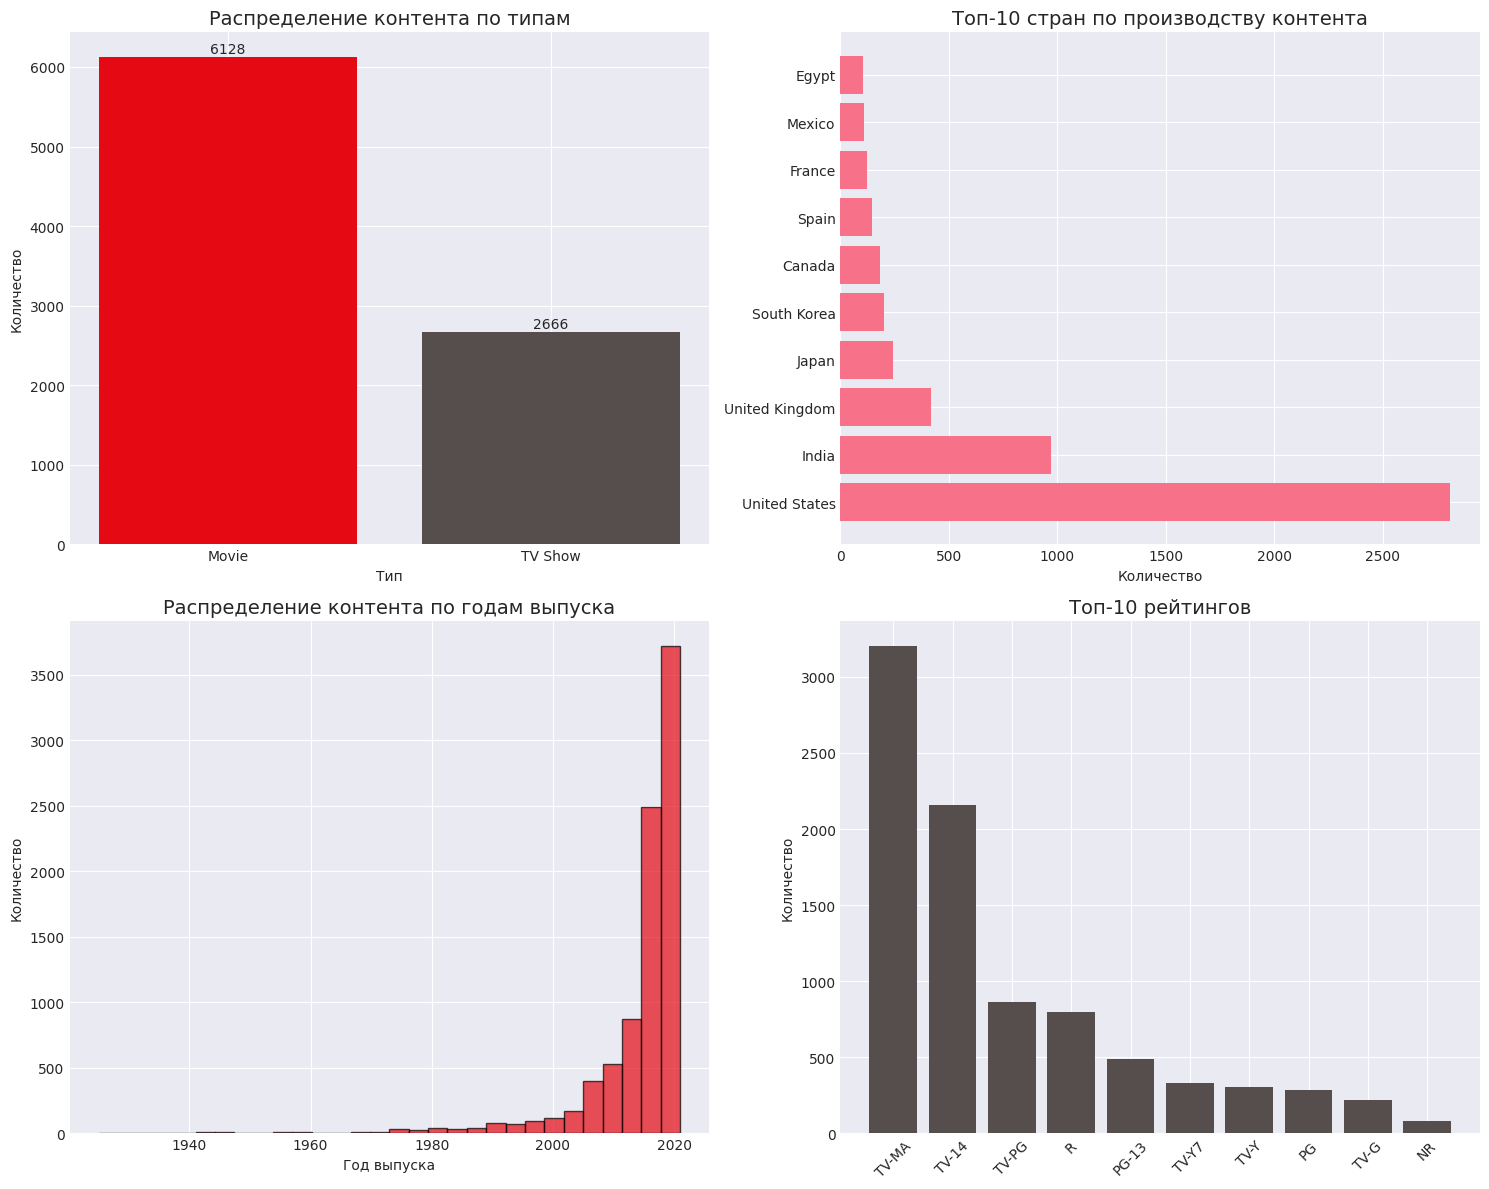

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

type_counts = df_clean['type'].value_counts()
axes[0, 0].bar(type_counts.index, type_counts.values, color=['#E50914', '#564d4d'])
axes[0, 0].set_title('Распределение контента по типам', fontsize=14)
axes[0, 0].set_xlabel('Тип')
axes[0, 0].set_ylabel('Количество')
for i, v in enumerate(type_counts.values):
    axes[0, 0].text(i, v + 50, str(v), ha='center')

top_countries = df_clean['country'].value_counts().head(10)
axes[0, 1].barh(range(len(top_countries)), top_countries.values)
axes[0, 1].set_yticks(range(len(top_countries)))
axes[0, 1].set_yticklabels(top_countries.index)
axes[0, 1].set_title('Топ-10 стран по производству контента', fontsize=14)
axes[0, 1].set_xlabel('Количество')

axes[1, 0].hist(df_clean['release_year'], bins=30, edgecolor='black', color='#E50914', alpha=0.7)
axes[1, 0].set_title('Распределение контента по годам выпуска', fontsize=14)
axes[1, 0].set_xlabel('Год выпуска')
axes[1, 0].set_ylabel('Количество')

rating_counts = df_clean['rating'].value_counts().head(10)
axes[1, 1].bar(range(len(rating_counts)), rating_counts.values, color='#564d4d')
axes[1, 1].set_xticks(range(len(rating_counts)))
axes[1, 1].set_xticklabels(rating_counts.index, rotation=45)
axes[1, 1].set_title('Топ-10 рейтингов', fontsize=14)
axes[1, 1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

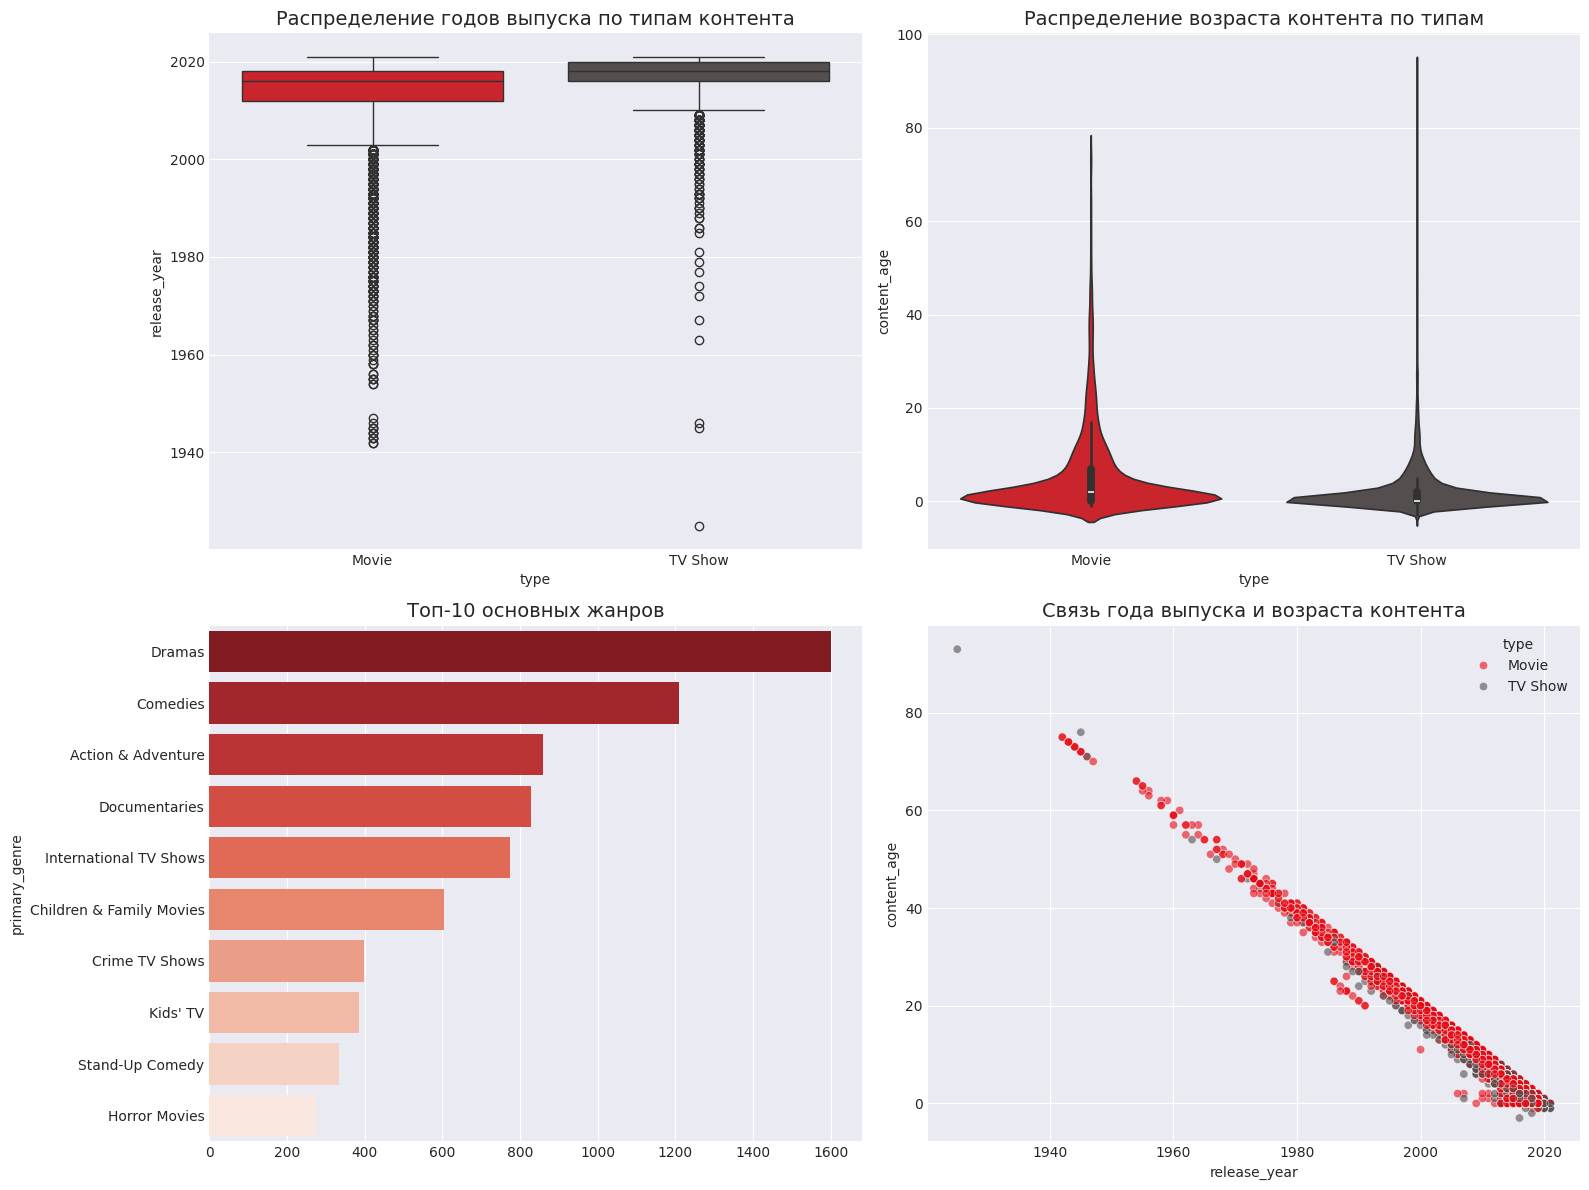

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=df_clean, x='type', y='release_year', ax=axes[0, 0], palette=['#E50914', '#564d4d'])
axes[0, 0].set_title('Распределение годов выпуска по типам контента', fontsize=14)

sns.violinplot(data=df_clean, x='type', y='content_age', ax=axes[0, 1], palette=['#E50914', '#564d4d'])
axes[0, 1].set_title('Распределение возраста контента по типам', fontsize=14)

top_genres = df_clean['primary_genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title('Топ-10 основных жанров', fontsize=14)

sns.scatterplot(data=df_clean, x='release_year', y='content_age', hue='type', 
                alpha=0.6, ax=axes[1, 1], palette=['#E50914', '#564d4d'])
axes[1, 1].set_title('Связь года выпуска и возраста контента', fontsize=14)

plt.tight_layout()
plt.show()

In [12]:
monthly_data = df_clean['month_added'].value_counts().sort_index()
fig1 = px.bar(x=monthly_data.index, y=monthly_data.values,
              labels={'x': 'Месяц', 'y': 'Количество'},
              title='Количество контента, добавленного по месяцам',
              color=monthly_data.values,
              color_continuous_scale='Reds')
fig1.update_layout(showlegend=False)
fig1.show()

country_type = df_clean.groupby(['country', 'type']).size().reset_index(name='count')
top20_countries = df_clean['country'].value_counts().head(20).index
country_type_top = country_type[country_type['country'].isin(top20_countries)]

fig2 = px.bar(country_type_top, x='country', y='count', color='type',
              title='Топ-20 стран: распределение фильмов и сериалов',
              labels={'count': 'Количество', 'country': 'Страна'},
              color_discrete_map={'Movie': '#E50914', 'TV Show': '#564d4d'},
              barmode='group')
fig2.update_layout(xaxis_tickangle=-45)
fig2.show()

yearly_trend = df_clean.groupby(['year_added', 'type']).size().reset_index(name='count')
fig3 = px.line(yearly_trend, x='year_added', y='count', color='type',
               title='Динамика добавления контента на Netflix по годам',
               labels={'year_added': 'Год добавления', 'count': 'Количество'},
               color_discrete_map={'Movie': '#E50914', 'TV Show': '#564d4d'})
fig3.update_traces(mode='lines+markers')
fig3.show()

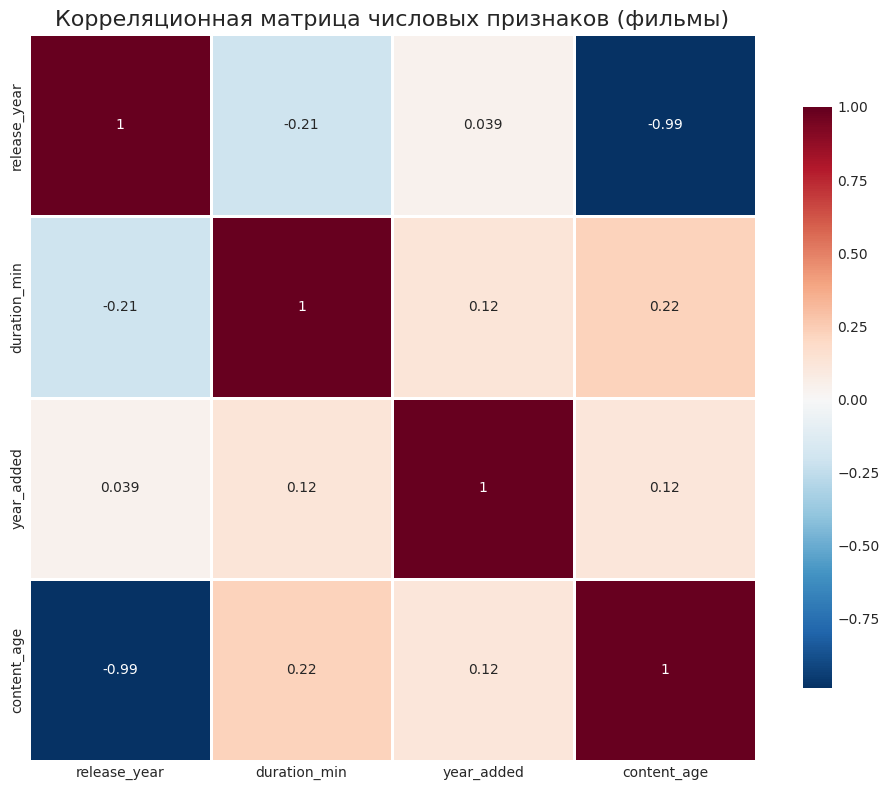

Анализ корреляций:
- Наибольшая отрицательная корреляция между release_year и content_age
- Это логично: чем новее фильм, тем меньше его возраст на момент добавления
- Длительность фильмов слабо коррелирует с другими признаками


In [13]:
numeric_cols = ['release_year', 'duration_numeric', 'year_added', 'month_added', 'content_age', 'type_encoded']
df_numeric = df_clean[numeric_cols].copy()

df_movies = df_clean[df_clean['type'] == 'Movie'].copy()
df_movies['duration_min'] = df_movies['duration_numeric']

corr_matrix = df_movies[['release_year', 'duration_min', 'year_added', 'content_age']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица числовых признаков (фильмы)', fontsize=16)
plt.tight_layout()
plt.show()

print("Анализ корреляций:")
print("- Наибольшая отрицательная корреляция между release_year и content_age")
print("- Это логично: чем новее фильм, тем меньше его возраст на момент добавления")
print("- Длительность фильмов слабо коррелирует с другими признаками")

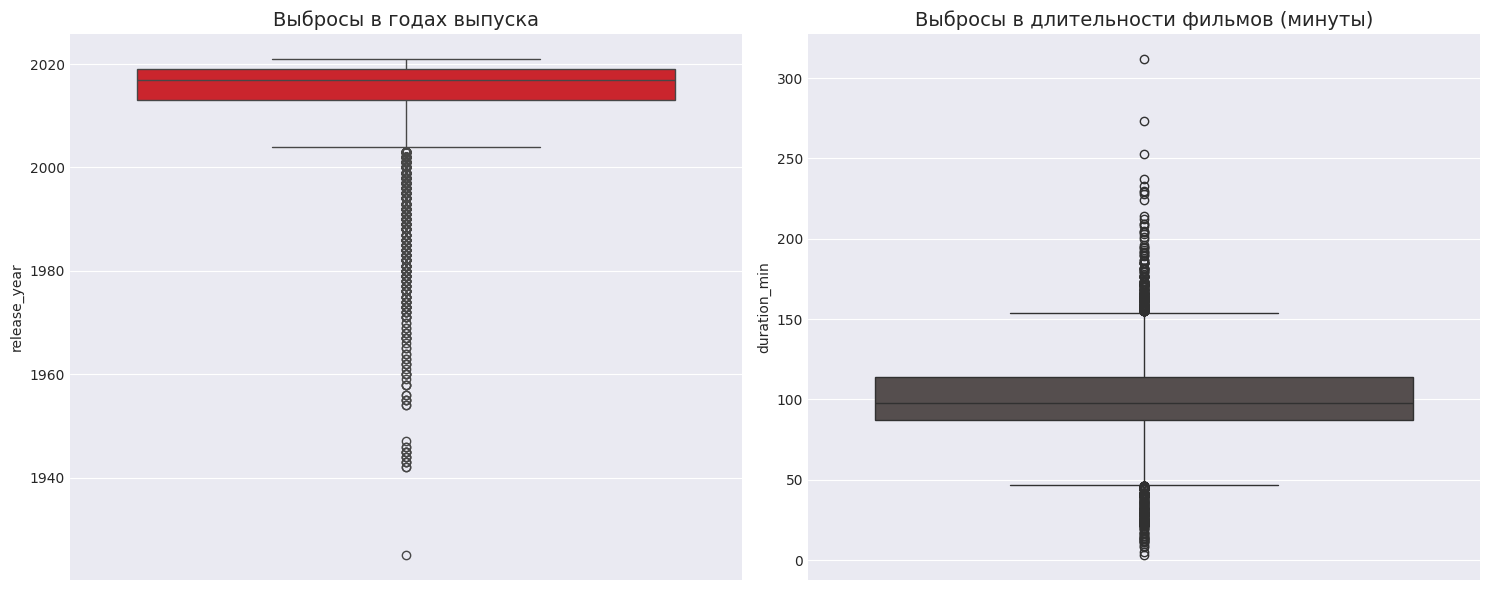

Найдено фильмов-выбросов по длительности: 450

Примеры фильмов-выбросов (необычная длительность):


,title,duration_min,release_year,rating
22,Avvai Shanmughi,161.0,1996,TV-PG
24,Jeans,166.0,1998,TV-14
45,My Heroes Were Cowboys,23.0,2021,PG
71,A StoryBots Space Adventure,13.0,2021,TV-Y
73,King of Boys,182.0,2018,TV-MA
166,Once Upon a Time in America,229.0,1984,R
177,The Guns of Navarone,156.0,1961,TV-14
202,Kyaa Kool Hai Hum,165.0,2005,TV-MA
341,Magnolia,189.0,1999,R
392,Django Unchained,165.0,2012,R


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df_clean, y='release_year', ax=axes[0], color='#E50914')
axes[0].set_title('Выбросы в годах выпуска', fontsize=14)

sns.boxplot(data=df_movies, y='duration_min', ax=axes[1], color='#564d4d')
axes[1].set_title('Выбросы в длительности фильмов (минуты)', fontsize=14)

plt.tight_layout()
plt.show()

Q1 = df_movies['duration_min'].quantile(0.25)
Q3 = df_movies['duration_min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_movies[(df_movies['duration_min'] < lower_bound) | 
                     (df_movies['duration_min'] > upper_bound)]

print(f"Найдено фильмов-выбросов по длительности: {len(outliers)}")
print("\nПримеры фильмов-выбросов (необычная длительность):")
outliers[['title', 'duration_min', 'release_year', 'rating']].head(10)

In [15]:
from sklearn.preprocessing import LabelEncoder

print(f"Уникальных стран: {df_clean['country'].nunique()}")

label_encoder = LabelEncoder()
df_clean['country_encoded'] = label_encoder.fit_transform(df_clean['country'])

print("\nLabel Encoding:")
print(df_clean[['country', 'country_encoded']].head(10))

top_10_countries = df_clean['country'].value_counts().head(10).index
for country in top_10_countries:
    df_clean[f'country_{country.replace(" ", "_")}'] = (df_clean['country'] == country).astype(int)

print("\nOne-Hot для топ-10 стран:")
df_clean[['country'] + [col for col in df_clean.columns if col.startswith('country_') and col != 'country_encoded']].head()

Уникальных стран: 748

Label Encoding:
                                             country  country_encoded
0                                      United States              603
1                                       South Africa              426
2                                                NaN              748
3                                                NaN              748
4                                              India              251
5                                                NaN              748
6                                                NaN              748
7  United States, Ghana, Burkina Faso, United Kin...              663
8                                     United Kingdom              506
9                                      United States              603

One-Hot для топ-10 стран:


,country,country_United_States,country_India,country_United_Kingdom,country_Japan,country_South_Korea,country_Canada,country_Spain,country_France,country_Mexico,country_Egypt
0,United States,1,0,0,0,0,0,0,0,0,0
1,South Africa,0,0,0,0,0,0,0,0,0,0
2,NaN,0,0,0,0,0,0,0,0,0,0
3,NaN,0,0,0,0,0,0,0,0,0,0
4,India,0,1,0,0,0,0,0,0,0,0


In [ ]:
"""
# ИТОГОВЫЕ ВЫВОДЫ ПО ДАТАСЕТУ NETFLIX

## Что я понял про датасет (7-12 пунктов):

1. **Состав данных**: Датасет содержит 8807 записей о фильмах и сериалах Netflix с 12 признаками.

2. **Пропуски**: Основные пропуски в колонках director (30%), cast (9%) и country (9%) - это естественно для контента, где эти данные могут отсутствовать.

3. **Дисбаланс типов**: Фильмов (6131) значительно больше, чем сериалов (2676) - примерно 70% против 30%.

4. **География**: США доминирует с 3238 единицами контента, далее Индия (972) и Великобритания (586).

5. **Временной диапазон**: Контент охватывает период с 1925 по 2021 год, но основная масса (95%) выпущена после 1999 года.

6. **Рейтинги**: Самый популярный рейтинг - TV-MA (для взрослых) с 3235 записями, что говорит о взрослой аудитории Netflix.

7. **Сезонность**: Пик добавления контента приходится на декабрь и январь (предновогодний период).

8. **Жанры**: Самые популярные основные жанры - International Movies, Dramas и Comedies.

9. **Возраст контента**: В среднем контент добавляется на Netflix через 2-3 года после выпуска.

## Гипотезы и наблюдения (3-5 пунктов):

1. **Гипотеза о влиянии страны на тип контента**: США производит больше фильмов, чем сериалов (≈70/30), в то время как Япония и Южная Корея имеют более высокую долю сериалов.

2. **Наблюдение о выбросах**: Есть фильмы с аномально большой длительностью (>200 минут) - это обычно документальные фильмы или редкие киноленты.

3. **Гипотеза о трендах**: После 2015 года резко выросло количество добавляемого контента, особенно сериалов - это коррелирует с расширением Netflix по миру.

4. **Наблюдение о возрасте контента**: Классические фильмы (до 2000 года) составляют менее 5% каталога - Netflix фокусируется на современном контенте.

## Что бы я сделал дальше:

1. **Построил бы модель классификации** для предсказания типа контента (фильм/сериал) на основе жанра, страны и года выпуска.

2. **Разработал бы рекомендательную систему** на основе жанров, актеров и режиссеров для предсказания популярности контента.

3. **Провел бы кластеризацию** контента по странам и жанрам для выявления региональных предпочтений.

4. **Исследовал бы временные ряды** для прогнозирования будущих трендов добавления контента.

## Какие подсказки брал у AI и что проверял руками:

1. **Feature Hashing**: Изучил документацию sklearn и применил для стран с большим числом уникальных значений.

2. **Интерпретация статистик**: Уточнил значения skewness и kurtosis для правильной интерпретации распределения.

3. **Обработка duration**: Создал регулярное выражение для извлечения чисел из строки с помощью str.extract().

4. **Plotly**: Настроил интерактивные графики с группировкой по цвету и кастомизацией.

*Всё остальное: очистка данных, визуализации, выводы и гипотезы - сделано самостоятельно на основе анализа данных.*
"""